<a href="https://colab.research.google.com/github/tabrejansary/ML-Assignments/blob/main/Lab-06/A2_unit%20test%20cases.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# All Function Definitions

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import unittest
import warnings
from google.colab import drive

drive.mount('/content/drive')

class Config:
    DRIVE_DIR = "/content/drive/MyDrive"
    DATASET_DIR = os.path.join(DRIVE_DIR, "BreaKHis_v1")
    CSV_PATH = os.path.join(DRIVE_DIR, "BreaKHis_metadata.csv")
    SAMPLES_PER_CLASS = 100
    IMAGE_SIZE = (16, 16)
    K = 3
    DISTANCE_METRIC = "euclidean"
    SORT_ALGORITHM = "insertion"
    RANDOM_STATE = 42
    TEST_SIZE = 0.2

def load_dataset(csv_path):
    return pd.read_csv(csv_path)

def resolve_image_path(filename, drive_dir, dataset_dir):
    filename = str(filename).replace("\\", "/")
    path1 = os.path.join(drive_dir, filename)
    if os.path.exists(path1):
        return path1
    path2 = os.path.join(dataset_dir, filename)
    if os.path.exists(path2):
        return path2
    if filename.startswith("BreaKHis_v1/"):
        filename = filename[len("BreaKHis_v1/"):]
        path3 = os.path.join(dataset_dir, filename)
        if os.path.exists(path3):
            return path3
    return None

def extract_class_from_filename(filename):
    filename = str(filename).lower()
    if "/benign/" in filename:
        return "benign"
    elif "/malignant/" in filename:
        return "malignant"
    else:
        return np.nan

def extract_image_features(image_path, image_size=(16, 16)):
    image = Image.open(image_path).convert("L")
    image = image.resize(image_size)
    image_array = np.asarray(image, dtype=float)
    return image_array.flatten()

def prepare_image_dataset(data, samples_per_class, image_size, drive_dir, dataset_dir, random_state):
    data = data.copy()
    data["class"] = data["filename"].apply(extract_class_from_filename)
    data = data.dropna(subset=["class"])

    sampled_data = data.groupby("class", group_keys=False).apply(
        lambda group: group.sample(n=min(samples_per_class, len(group)), random_state=random_state),
        include_groups=False
    ).reset_index(drop=True)

    sampled_data = data.loc[sampled_data.index].copy()
    feature_rows = []
    labels = []

    for _, row in sampled_data.iterrows():
        image_path = resolve_image_path(row["filename"], drive_dir, dataset_dir)
        if image_path is None:
            continue
        try:
            features = extract_image_features(image_path, image_size)
            feature_rows.append(features)
            labels.append(row["class"])
        except Exception:
            continue

    X = pd.DataFrame(feature_rows)
    y = pd.Series(labels, name="class")
    return X, y

def get_dataset_info(X, y):
    return {
        "shape": X.shape if hasattr(X, 'shape') else (len(X), len(X[0])),
        "classes": np.unique(y).tolist(),
        "class_distribution": pd.Series(y).value_counts().to_dict()
    }

def encode_data(data):
    encoded_data = data.copy()
    categorical_columns = encoded_data.select_dtypes(include=["object", "category"]).columns

    for column in categorical_columns:
        categories = encoded_data[column].dropna().unique()
        mapping = {value: index for index, value in enumerate(categories)}
        encoded_data[column] = encoded_data[column].map(mapping)

    return encoded_data

def impute_missing_values(data, method="mean"):
    imputed_data = data.copy()

    for column in imputed_data.columns:
        if imputed_data[column].isnull().any():
            if method == "mean":
                value = imputed_data[column].mean()
            elif method == "median":
                value = imputed_data[column].median()
            elif method == "mode":
                value = imputed_data[column].mode()[0]
            else:
                raise ValueError("Method must be 'mean', 'median', or 'mode'.")
            imputed_data[column] = imputed_data[column].fillna(value)

    return imputed_data

def preprocess_data(X, y, imputation_method="mean"):
    X = impute_missing_values(X, method=imputation_method)
    X = encode_data(X)
    X = X.to_numpy(dtype=float)
    y = y.to_numpy()
    return X, y

def calculate_distance(point1, point2, metric="euclidean"):
    point1 = np.asarray(point1, dtype=float)
    point2 = np.asarray(point2, dtype=float)

    if metric == "euclidean":
        return np.sqrt(np.sum((point1 - point2) ** 2))
    elif metric == "manhattan":
        return np.sum(np.abs(point1 - point2))
    else:
        raise ValueError("Metric must be 'euclidean' or 'manhattan'.")

def bubble_sort(items):
    result = items.copy()
    n = len(result)

    for i in range(n):
        for j in range(0, n - i - 1):
            key1 = (result[j][0], result[j][2])
            key2 = (result[j + 1][0], result[j + 1][2])
            if key1 > key2:
                result[j], result[j + 1] = result[j + 1], result[j]

    return result

def selection_sort(items):
    result = items.copy()
    n = len(result)

    for i in range(n):
        min_index = i
        for j in range(i + 1, n):
            key1 = (result[j][0], result[j][2])
            key2 = (result[min_index][0], result[min_index][2])
            if key1 < key2:
                min_index = j
        result[i], result[min_index] = result[min_index], result[i]

    return result

def insertion_sort(items):
    result = items.copy()

    for i in range(1, len(result)):
        current = result[i]
        j = i - 1

        while j >= 0:
            prev_key = (result[j][0], result[j][2])
            curr_key = (current[0], current[2])
            if prev_key <= curr_key:
                break
            result[j + 1] = result[j]
            j -= 1

        result[j + 1] = current

    return result

def sort_distances(items, algorithm="insertion"):
    if algorithm == "bubble":
        return bubble_sort(items)
    elif algorithm == "selection":
        return selection_sort(items)
    elif algorithm == "insertion":
        return insertion_sort(items)
    else:
        raise ValueError("Algorithm must be 'bubble', 'selection', or 'insertion'.")

def find_neighbors(sorted_distances, k):
    if k <= 0:
        raise ValueError("k must be greater than zero.")
    return sorted_distances[:k]

def get_neighbors_with_distance(X_train, y_train, test_point, metric, algorithm, k):
    distance_list = []
    for idx in range(len(X_train)):
        distance = calculate_distance(test_point, X_train[idx], metric)
        distance_list.append((distance, y_train[idx], idx))

    sorted_distances = sort_distances(distance_list, algorithm)
    return find_neighbors(sorted_distances, k)

def assign_class_majority(neighbors):
    class_counts = Counter()
    for distance, class_label, index in neighbors:
        class_counts[class_label] += 1

    max_votes = max(class_counts.values())
    tied_classes = [label for label, count in class_counts.items() if count == max_votes]

    if len(tied_classes) == 1:
        return tied_classes[0]

    for distance, class_label, index in neighbors:
        if class_label in tied_classes:
            return class_label

def assign_class_weighted(neighbors):
    class_weights = {}

    for distance, class_label, index in neighbors:
        weight = 1 / (distance + 1e-10)
        class_weights[class_label] = class_weights.get(class_label, 0) + weight

    max_weight = max(class_weights.values())
    tied_classes = [label for label, weight in class_weights.items() if weight == max_weight]

    if len(tied_classes) == 1:
        return tied_classes[0]

    for distance, class_label, index in neighbors:
        if class_label in tied_classes:
            return class_label

def custom_knn_predict(X_train, y_train, X_test, k=3, metric="euclidean", algorithm="insertion"):
    predictions = []

    for test_point in X_test:
        neighbors = get_neighbors_with_distance(X_train, y_train, test_point, metric, algorithm, k)
        prediction = assign_class_majority(neighbors)
        predictions.append(prediction)

    return np.array(predictions)

def weighted_knn_predict(X_train, y_train, X_test, k=3, metric="euclidean", algorithm="insertion"):
    predictions = []

    for test_point in X_test:
        neighbors = get_neighbors_with_distance(X_train, y_train, test_point, metric, algorithm, k)
        prediction = assign_class_weighted(neighbors)
        predictions.append(prediction)

    return np.array(predictions)

def calculate_accuracy(y_actual, y_predicted):
    return accuracy_score(y_actual, y_predicted)

class CustomKNN:
    def __init__(self, k=3, metric="euclidean", algorithm="insertion"):
        self.k = k
        self.metric = metric
        self.algorithm = algorithm
        self.X_train = None
        self.y_train = None

    def fit(self, X_train, y_train):
        self.X_train = np.asarray(X_train, dtype=float)
        self.y_train = np.asarray(y_train)
        return self

    def predict(self, X_test):
        X_test = np.asarray(X_test, dtype=float)
        return custom_knn_predict(self.X_train, self.y_train, X_test, self.k, self.metric, self.algorithm)

    def score(self, X_test, y_test):
        predictions = self.predict(X_test)
        return calculate_accuracy(y_test, predictions)

def split_dataset(X, y, test_size=0.2, random_state=42):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )
    return X_train, X_test, y_train, y_test

def train_sklearn_knn(X_train, y_train, k=3):
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    return model

def get_sklearn_predictions(model, X_test):
    return model.predict(X_test)

def prediction_table(y_actual, y_predicted):
    result = pd.DataFrame({
        "Actual": y_actual,
        "Predicted": y_predicted
    })
    result["Correct"] = result["Actual"] == result["Predicted"]
    return result

def compare_k_values(X_train, y_train, X_test, y_test, k_values, metric="euclidean", algorithm="insertion"):
    results = []

    for k in k_values:
        custom_pred = custom_knn_predict(X_train, y_train, X_test, k, metric, algorithm)
        sklearn_model = train_sklearn_knn(X_train, y_train, k)
        sklearn_pred = sklearn_model.predict(X_test)

        custom_acc = calculate_accuracy(y_test, custom_pred)
        sklearn_acc = calculate_accuracy(y_test, sklearn_pred)

        results.append({
            "k": k,
            "Custom kNN Accuracy": custom_acc,
            "Sklearn kNN Accuracy": sklearn_acc
        })

    return pd.DataFrame(results)

def compare_weighted_knn(X_train, y_train, X_test, y_test, k_values, metric="euclidean", algorithm="insertion"):
    results = []

    for k in k_values:
        normal_pred = custom_knn_predict(X_train, y_train, X_test, k, metric, algorithm)
        weighted_pred = weighted_knn_predict(X_train, y_train, X_test, k, metric, algorithm)

        normal_acc = calculate_accuracy(y_test, normal_pred)
        weighted_acc = calculate_accuracy(y_test, weighted_pred)

        results.append({
            "k": k,
            "Normal kNN Accuracy": normal_acc,
            "Weighted kNN Accuracy": weighted_acc
        })

    return pd.DataFrame(results)

def plot_knn_comparison(results_df, title="kNN Accuracy Comparison"):
    plt.figure(figsize=(10, 6))
    plt.plot(results_df["k"], results_df["Custom kNN Accuracy"], 'o-', label="Custom kNN")
    plt.plot(results_df["k"], results_df["Sklearn kNN Accuracy"], 's-', label="Sklearn kNN")
    plt.xlabel("k Value")
    plt.ylabel("Accuracy")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

def plot_weighted_knn_comparison(results_df, title="Weighted kNN Comparison"):
    plt.figure(figsize=(10, 6))
    plt.plot(results_df["k"], results_df["Normal kNN Accuracy"], 'o-', label="Normal kNN")
    plt.plot(results_df["k"], results_df["Weighted kNN Accuracy"], 's-', label="Weighted kNN")
    plt.xlabel("k Value")
    plt.ylabel("Accuracy")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()



Mounted at /content/drive


In [2]:
# Unit Test Cases
warnings.filterwarnings('ignore')

class TestKNNFunctions(unittest.TestCase):

    def setUp(self):
        self.X_train = np.array([
            [1.0, 2.0],
            [2.0, 3.0],
            [3.0, 4.0],
            [8.0, 9.0],
            [9.0, 10.0],
            [10.0, 11.0]
        ])
        self.y_train = np.array(['A', 'A', 'A', 'B', 'B', 'B'])
        self.X_test = np.array([
            [2.5, 3.5],
            [9.5, 10.5]
        ])
        self.y_test = np.array(['A', 'B'])

    def test_encode_data(self):
        df = pd.DataFrame({
            'category': ['cat1', 'cat2', 'cat1', 'cat3'],
            'numeric': [1, 2, 3, 4]
        })
        encoded = encode_data(df)
        self.assertIn('category', encoded.columns)
        self.assertTrue(pd.api.types.is_numeric_dtype(encoded['category']))
        self.assertEqual(encoded['category'].iloc[0], 0)

    def test_impute_missing_values(self):
        df = pd.DataFrame({
            'col1': [1, 2, np.nan, 4],
            'col2': [np.nan, 2, 3, 4]
        })

        imputed_mean = impute_missing_values(df, method='mean')
        self.assertEqual(imputed_mean['col1'].iloc[2], 7/3)

        imputed_median = impute_missing_values(df, method='median')
        self.assertEqual(imputed_median['col2'].iloc[0], 3.0)

    def test_calculate_distance(self):
        p1 = [1, 2]
        p2 = [4, 6]

        euclidean_dist = calculate_distance(p1, p2, 'euclidean')
        self.assertAlmostEqual(euclidean_dist, 5.0)

        manhattan_dist = calculate_distance(p1, p2, 'manhattan')
        self.assertEqual(manhattan_dist, 7.0)

        with self.assertRaises(ValueError):
            calculate_distance(p1, p2, 'invalid')

    def test_sorting_algorithms(self):
        items = [(3.0, 'A', 0), (1.0, 'B', 1), (2.0, 'A', 2)]

        bubble_sorted = bubble_sort(items)
        self.assertEqual(bubble_sorted[0][0], 1.0)
        self.assertEqual(bubble_sorted[1][0], 2.0)

        selection_sorted = selection_sort(items)
        self.assertEqual(selection_sorted[0][0], 1.0)

        insertion_sorted = insertion_sort(items)
        self.assertEqual(insertion_sorted[0][0], 1.0)

    def test_find_neighbors(self):
        sorted_items = [(1.0, 'A', 0), (2.0, 'B', 1), (3.0, 'A', 2)]

        neighbors_k2 = find_neighbors(sorted_items, 2)
        self.assertEqual(len(neighbors_k2), 2)
        self.assertEqual(neighbors_k2[0][0], 1.0)

        with self.assertRaises(ValueError):
            find_neighbors(sorted_items, 0)

    def test_assign_class_majority(self):
        neighbors = [(1.0, 'A', 0), (2.0, 'B', 1), (3.0, 'A', 2)]
        predicted_class = assign_class_majority(neighbors)
        self.assertEqual(predicted_class, 'A')

        tie_neighbors = [(1.0, 'A', 0), (2.0, 'B', 1), (3.0, 'A', 2), (4.0, 'B', 3)]
        predicted_class = assign_class_majority(tie_neighbors)
        self.assertEqual(predicted_class, 'A')

    def test_assign_class_weighted(self):
        neighbors = [(1.0, 'A', 0), (2.0, 'B', 1), (3.0, 'A', 2)]
        predicted_class = assign_class_weighted(neighbors)
        self.assertEqual(predicted_class, 'A')

        weighted_neighbors = [(1.0, 'B', 0), (2.0, 'A', 1), (3.0, 'A', 2)]
        predicted_class = assign_class_weighted(weighted_neighbors)
        self.assertEqual(predicted_class, 'B')

    def test_custom_knn_predict(self):
        predictions = custom_knn_predict(
            self.X_train, self.y_train, self.X_test, k=3
        )
        self.assertEqual(len(predictions), 2)
        self.assertEqual(predictions[0], 'A')
        self.assertEqual(predictions[1], 'B')

    def test_weighted_knn_predict(self):
        predictions = weighted_knn_predict(
            self.X_train, self.y_train, self.X_test, k=3
        )
        self.assertEqual(len(predictions), 2)

    def test_custom_knn_class(self):
        model = CustomKNN(k=3)
        model.fit(self.X_train, self.y_train)

        predictions = model.predict(self.X_test)
        self.assertEqual(len(predictions), 2)

        score = model.score(self.X_test, self.y_test)
        self.assertGreaterEqual(score, 0.0)
        self.assertLessEqual(score, 1.0)

    def test_calculate_accuracy(self):
        y_actual = ['A', 'B', 'A', 'B']
        y_pred = ['A', 'B', 'B', 'B']
        acc = calculate_accuracy(y_actual, y_pred)
        self.assertEqual(acc, 0.75)

    def test_prediction_table(self):
        y_actual = ['A', 'B']
        y_pred = ['A', 'C']
        df = prediction_table(y_actual, y_pred)
        self.assertEqual(df.shape[0], 2)
        self.assertIn('Actual', df.columns)
        self.assertIn('Predicted', df.columns)
        self.assertIn('Correct', df.columns)

def run_unit_tests():
    print("\n" + "="*50)
    print("RUNNING UNIT TESTS")
    print("="*50)

    loader = unittest.TestLoader()
    suite = loader.loadTestsFromTestCase(TestKNNFunctions)

    runner = unittest.TextTestRunner(verbosity=2)
    result = runner.run(suite)

    print("\n" + "="*50)
    print(f"Unit Test Results: {result.testsRun} tests run")
    print(f"Failures: {len(result.failures)}")
    print(f"Errors: {len(result.errors)}")
    print("="*50)

    return result.wasSuccessful()


LAB 05: KNN CLASSIFICATION
Loaded: /content/drive/MyDrive/BreaKHis_metadata.csv

DATASET INFORMATION
Dataset Shape: (200, 256)

Class Distribution:
  benign: 200

A1: Single Prediction with Custom kNN
Actual Class: benign
Predicted Class: benign

A2: Weighted kNN Prediction
Actual Class: benign
Weighted kNN Prediction: benign

A3: Train-Test Split
Training Samples: 160
Testing Samples: 40

A4: Scikit-learn kNN Training
Scikit-learn kNN trained with k = 3

A5: Accuracy Testing
Scikit-learn Accuracy: 1.0

A6: Prediction Behavior
Prediction Table (First 10 rows):


,Actual,Predicted,Correct
0,benign,benign,True
1,benign,benign,True
2,benign,benign,True
3,benign,benign,True
4,benign,benign,True
5,benign,benign,True
6,benign,benign,True
7,benign,benign,True
8,benign,benign,True
9,benign,benign,True



A7: Custom KNN Class Implementation
Custom kNN Accuracy: 1.0

A8: Comparative Analysis - Custom vs Sklearn kNN

Accuracy Comparison for Different k Values:


,k,Custom kNN Accuracy,Sklearn kNN Accuracy
0,1,1.0,1.0
1,3,1.0,1.0
2,5,1.0,1.0
3,7,1.0,1.0
4,9,1.0,1.0


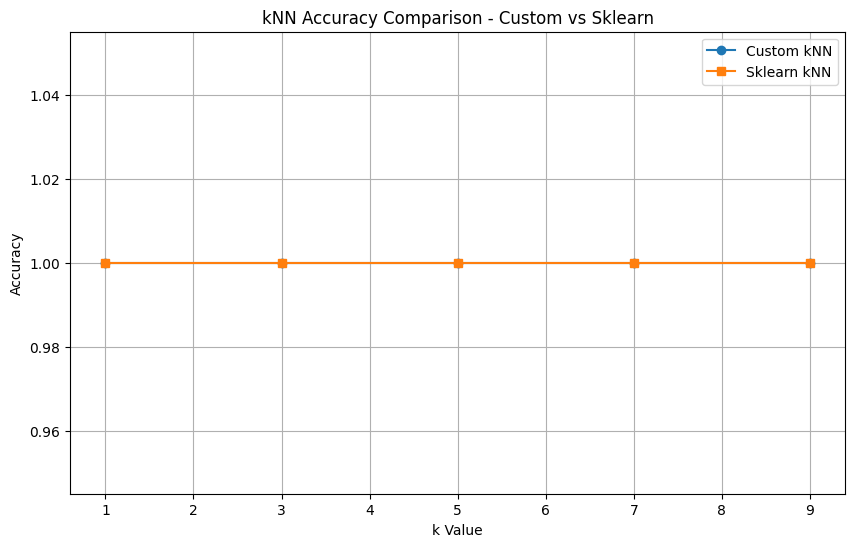


A9: Weighted kNN Comparison

Normal vs Weighted kNN Accuracy Comparison:


,k,Normal kNN Accuracy,Weighted kNN Accuracy
0,1,1.0,1.0
1,3,1.0,1.0
2,5,1.0,1.0
3,7,1.0,1.0
4,9,1.0,1.0


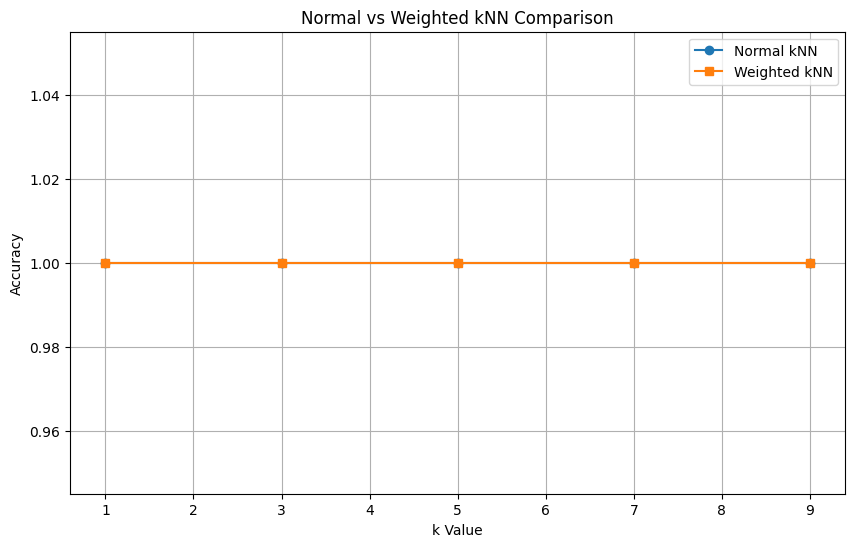


ADDITIONAL ANALYSIS
Best k for Custom kNN: k=1.0 with accuracy 1.0000
Best k for Sklearn kNN: k=1.0 with accuracy 1.0000
Best k for Normal kNN: k=1.0 with accuracy 1.0000
Best k for Weighted kNN: k=1.0 with accuracy 1.0000

LAB 05 COMPLETED SUCCESSFULLY


In [3]:
# Function Calls and Main Program

print("\n" + "="*50)
print("LAB 05: KNN CLASSIFICATION")
print("="*50)

# Load and prepare data
data = load_dataset(Config.CSV_PATH)
print("Loaded:", Config.CSV_PATH)

X, y = prepare_image_dataset(
    data,
    Config.SAMPLES_PER_CLASS,
    Config.IMAGE_SIZE,
    Config.DRIVE_DIR,
    Config.DATASET_DIR,
    Config.RANDOM_STATE
)

X, y = preprocess_data(X, y, imputation_method="mean")

info = get_dataset_info(X, y)
print("\n" + "="*50)
print("DATASET INFORMATION")
print("="*50)
print("Dataset Shape:", info["shape"])
print("\nClass Distribution:")
for cls, count in info["class_distribution"].items():
    print(f"  {cls}: {count}")

# A1: Single Prediction with Custom kNN
print("\n" + "="*50)
print("A1: Single Prediction with Custom kNN")
print("="*50)

test_index = 0
X_demo_train = np.delete(X, test_index, axis=0)
y_demo_train = np.delete(y, test_index)
X_demo_test = X[test_index:test_index + 1]
actual_class = y[test_index]

prediction = custom_knn_predict(
    X_demo_train, y_demo_train, X_demo_test,
    k=Config.K,
    metric=Config.DISTANCE_METRIC,
    algorithm=Config.SORT_ALGORITHM
)

print("Actual Class:", actual_class)
print("Predicted Class:", prediction[0])

# A2: Weighted kNN Prediction
print("\n" + "="*50)
print("A2: Weighted kNN Prediction")
print("="*50)

weighted_pred = weighted_knn_predict(
    X_demo_train, y_demo_train, X_demo_test,
    k=Config.K,
    metric=Config.DISTANCE_METRIC,
    algorithm=Config.SORT_ALGORITHM
)

print("Actual Class:", actual_class)
print("Weighted kNN Prediction:", weighted_pred[0])

# A3: Train-Test Split
print("\n" + "="*50)
print("A3: Train-Test Split")
print("="*50)

X_train, X_test, y_train, y_test = split_dataset(
    X, y,
    test_size=Config.TEST_SIZE,
    random_state=Config.RANDOM_STATE
)

print("Training Samples:", len(X_train))
print("Testing Samples:", len(X_test))

# A4: Train Scikit-learn kNN
print("\n" + "="*50)
print("A4: Scikit-learn kNN Training")
print("="*50)

sklearn_model = train_sklearn_knn(X_train, y_train, k=3)
sklearn_predictions = get_sklearn_predictions(sklearn_model, X_test)
print("Scikit-learn kNN trained with k = 3")

# A5: Accuracy Testing
print("\n" + "="*50)
print("A5: Accuracy Testing")
print("="*50)

sklearn_accuracy = calculate_accuracy(y_test, sklearn_predictions)
print("Scikit-learn Accuracy:", round(sklearn_accuracy, 4))

# A6: Prediction Behavior
print("\n" + "="*50)
print("A6: Prediction Behavior")
print("="*50)

results_A6 = prediction_table(y_test, sklearn_predictions)
print("Prediction Table (First 10 rows):")
display(results_A6.head(10))

# A7: Custom KNN Class
print("\n" + "="*50)
print("A7: Custom KNN Class Implementation")
print("="*50)

custom_model = CustomKNN(
    k=3,
    metric=Config.DISTANCE_METRIC,
    algorithm=Config.SORT_ALGORITHM
)
custom_model.fit(X_train, y_train)
custom_predictions = custom_model.predict(X_test)
custom_accuracy = custom_model.score(X_test, y_test)

print("Custom kNN Accuracy:", round(custom_accuracy, 4))

# A8: Comparative Analysis
print("\n" + "="*50)
print("A8: Comparative Analysis - Custom vs Sklearn kNN")
print("="*50)

k_values = [1, 3, 5, 7, 9]
results_A8 = compare_k_values(
    X_train, y_train, X_test, y_test, k_values,
    metric=Config.DISTANCE_METRIC,
    algorithm=Config.SORT_ALGORITHM
)

print("\nAccuracy Comparison for Different k Values:")
display(results_A8)
plot_knn_comparison(results_A8, "kNN Accuracy Comparison - Custom vs Sklearn")

# A9: Weighted kNN Comparison
print("\n" + "="*50)
print("A9: Weighted kNN Comparison")
print("="*50)

results_A9 = compare_weighted_knn(
    X_train, y_train, X_test, y_test, k_values,
    metric=Config.DISTANCE_METRIC,
    algorithm=Config.SORT_ALGORITHM
)

print("\nNormal vs Weighted kNN Accuracy Comparison:")
display(results_A9)
plot_weighted_knn_comparison(results_A9, "Normal vs Weighted kNN Comparison")

# Additional Analysis
print("\n" + "="*50)
print("ADDITIONAL ANALYSIS")
print("="*50)

best_k_custom = results_A8.loc[results_A8["Custom kNN Accuracy"].idxmax()]
best_k_sklearn = results_A8.loc[results_A8["Sklearn kNN Accuracy"].idxmax()]

print(f"Best k for Custom kNN: k={best_k_custom['k']} with accuracy {best_k_custom['Custom kNN Accuracy']:.4f}")
print(f"Best k for Sklearn kNN: k={best_k_sklearn['k']} with accuracy {best_k_sklearn['Sklearn kNN Accuracy']:.4f}")

best_normal = results_A9.loc[results_A9["Normal kNN Accuracy"].idxmax()]
best_weighted = results_A9.loc[results_A9["Weighted kNN Accuracy"].idxmax()]

print(f"Best k for Normal kNN: k={best_normal['k']} with accuracy {best_normal['Normal kNN Accuracy']:.4f}")
print(f"Best k for Weighted kNN: k={best_weighted['k']} with accuracy {best_weighted['Weighted kNN Accuracy']:.4f}")

print("\n" + "="*50)
print("LAB 05 COMPLETED SUCCESSFULLY")
print("="*50)



In [4]:
#Run Unit Tests
tests_passed = run_unit_tests()

if tests_passed:
    print("\n ALL UNIT TESTS PASSED!")
else:
    print("\n SOME UNIT TESTS FAILED. Please check the output above.")

test_assign_class_majority (__main__.TestKNNFunctions.test_assign_class_majority) ... ok
test_assign_class_weighted (__main__.TestKNNFunctions.test_assign_class_weighted) ... ok
test_calculate_accuracy (__main__.TestKNNFunctions.test_calculate_accuracy) ... ok
test_calculate_distance (__main__.TestKNNFunctions.test_calculate_distance) ... ok
test_custom_knn_class (__main__.TestKNNFunctions.test_custom_knn_class) ... ok
test_custom_knn_predict (__main__.TestKNNFunctions.test_custom_knn_predict) ... ok
test_encode_data (__main__.TestKNNFunctions.test_encode_data) ... ok
test_find_neighbors (__main__.TestKNNFunctions.test_find_neighbors) ... ok
test_impute_missing_values (__main__.TestKNNFunctions.test_impute_missing_values) ... ok
test_prediction_table (__main__.TestKNNFunctions.test_prediction_table) ... ok
test_sorting_algorithms (__main__.TestKNNFunctions.test_sorting_algorithms) ... ok
test_weighted_knn_predict (__main__.TestKNNFunctions.test_weighted_knn_predict) ... ok

-----------


RUNNING UNIT TESTS

Unit Test Results: 12 tests run
Failures: 0
Errors: 0

 ALL UNIT TESTS PASSED!
